In [1]:
# 1. 호환성 문제를 일으키는 numpy 2.0을 1.x대로 낮추고 관련 라이브러리 설치
!pip install "numpy<2" "matplotlib<3.9" pmdarima arch --force-reinstall

  Using cached numpy-1.26.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Using cached matplotlib-3.8.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (11.6 MB)
  Using cached pmdarima-2.0.4-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.1 MB)
  Using cached arch-7.2.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (986 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached packaging-26.0-py3-none-any.whl (74 kB)
  Using cached contourpy-1.3.0-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (321 kB)
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from arch import arch_model
import arch.data.sp500

# 그래프 스타일 및 한글 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='NanumBarunGothic')

/opt/conda/lib/python3.9/site-packages/IPython/core/pylabtools.py:137: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


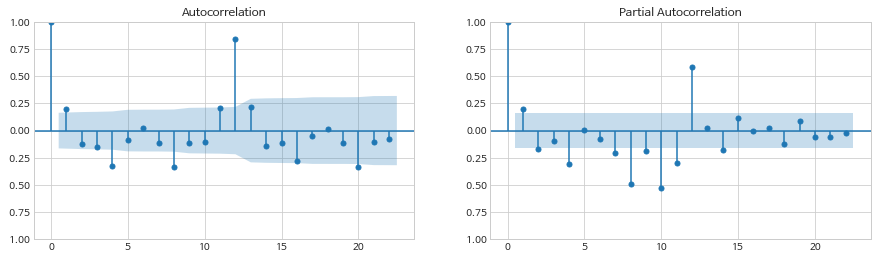

In [5]:
# 1. 데이터 로드  
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
ap = pd.read_csv(url)
ap.drop('Month', axis=1, inplace=True)

# 2. 로그 변환: 시간 흐름에 따라 커지는 분산을 안정화하기 위해 수행 [cite: 19]
ap_transformed = np.log(ap)

# 3. 차분 : 추세를 제거하여 평균을 일정하게 만듦 [cite: 18, 20]
# 변화량만 추출하여 정상성 데이터로 변환하는 과정임 
ap_diff = ap_transformed.diff().dropna()

# 4. 시각화: ACF/PACF 플롯 확인
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(ap_diff, ax=axes[0])
plot_pacf(ap_diff, ax=axes[1])
plt.show()
 

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=-371.453, Time=2.46 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-271.901, Time=0.06 sec


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-366.335, Time=1.00 sec


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,1)(0,1,1)[12] intercept   : AIC=-375.750, Time=1.57 sec


/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,0)(0,1,1)[12]             : AIC=-371.664, Time=1.21 sec

Best model:  ARIMA(2,0,0)(0,1,1)[12] intercept
Total fit time: 71.890 seconds
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  115
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 194.449
Date:                              Fri, 20 Feb 2026   AIC                           -378.898
Time:                                      06:40:05   BIC                           -365.725
Sample:                                           0   HQIC                          -373.562
                                              - 115                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


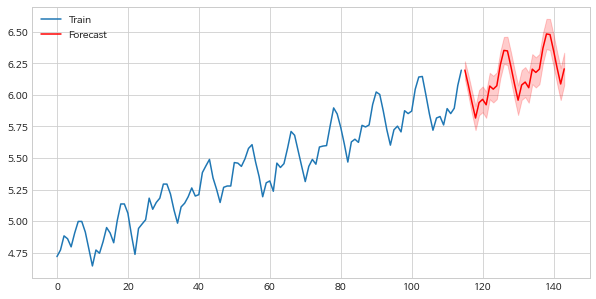

In [4]:
# 1. 데이터 분할 (80% 학습, 20% 테스트)
train_size = int(len(ap_transformed) * 0.8)
train, test = ap_transformed[:train_size], ap_transformed[train_size:]

# 2. AutoARIMA 실행: AIC가 가장 낮은 모델을 최적 모델로 선정함
# ARIMA는 과거 데이터(AR), 추세 제거(I), 과거 오차(MA)를 합친 모델임 [cite: 12, 13]
model = pm.auto_arima(train, seasonal=True, m=12, trace=True, suppress_warnings=True)

# 3. 최적 모델 요약 확인
print(model.summary())

# 4. 예측 결과 시각화
preds, conf_int = model.predict(n_periods=len(test), return_conf_int=True)
plt.figure(figsize=(10, 5))
plt.plot(train, label='Train')
plt.plot(test.index, preds, label='Forecast', color='red')
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], alpha=0.2, color='red')
plt.legend()
plt.show()
 

                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6936.72
Distribution:                  Normal   AIC:                           13881.4
Method:            Maximum Likelihood   BIC:                           13907.5
                                        No. Observations:                 5030
Date:                Fri, Feb 20 2026   Df Residuals:                     5029
Time:                        06:40:28   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0564  1.149e-02      4.906  9.302e-07 [3.

/opt/conda/lib/python3.9/site-packages/IPython/core/pylabtools.py:137: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


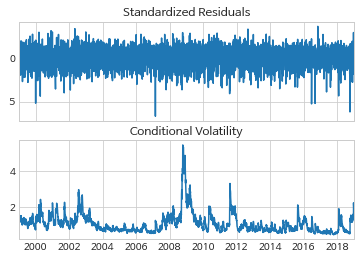

In [6]:
# 1. S&P 500 수익률 데이터 준비
data = arch.data.sp500.load()
returns = 100 * data["Adj Close"].pct_change().dropna()

# 2. ARCH/GARCH 모델 적합
# ARIMA가 평균적인 시간 패턴을 배운다면, GARCH는 변동성(분산)의 범위를 보완함 [cite: 28, 31, 48]
am = arch_model(returns, vol='Garch', p=1, q=1)
res = am.fit(disp='off')

# 3. 결과 요약 및 시각화 확인
print(res.summary())
res.plot()
plt.show()